# PT Transfer Synchronism Analysis

This notebook analyzes transfer synchronism for travelers who use at least two PT legs in the same trip.
For each transfer, it computes:
- transfer time (arrival of PT leg $i$ to departure of PT leg $i+1$)
- walking time between PT legs
- waiting time between PT legs
- walking distance between PT legs

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from pt_transfer_analysis import analyze_pt_transfer_synchronism, seconds_to_hhmmss

In [8]:
legs_path = Path('Simulation/output/output_legs.csv.gz')

result = analyze_pt_transfer_synchronism(legs_path, transfer_modes=('walk',))
transfers = result.transfers
person_summary = result.person_summary
trip_summary = result.trip_summary
global_summary = result.global_summary

print(f'Transfer events found: {len(transfers):,}')
print(f'Agents with transfers: {global_summary["n_agents_with_transfers"]:,}')

Transfer events found: 153,168
Agents with transfers: 88,079


In [9]:
summary_view = pd.Series(global_summary, name='value').to_frame()
summary_view.loc['mean_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['mean_transfer_time_s'])
summary_view.loc['median_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['median_transfer_time_s'])
summary_view.loc['p95_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['p95_transfer_time_s'])
summary_view

,value
n_agents_with_transfers,88079.0
n_trips_with_transfers,109745.0
n_transfer_events,153168.0
mean_transfer_time_s,46.25993
median_transfer_time_s,24.0
p95_transfer_time_s,137.0
mean_transfer_distance_m,41.361107
median_transfer_distance_m,24.0
p95_transfer_distance_m,119.0
total_transfer_time_s,7085541.0


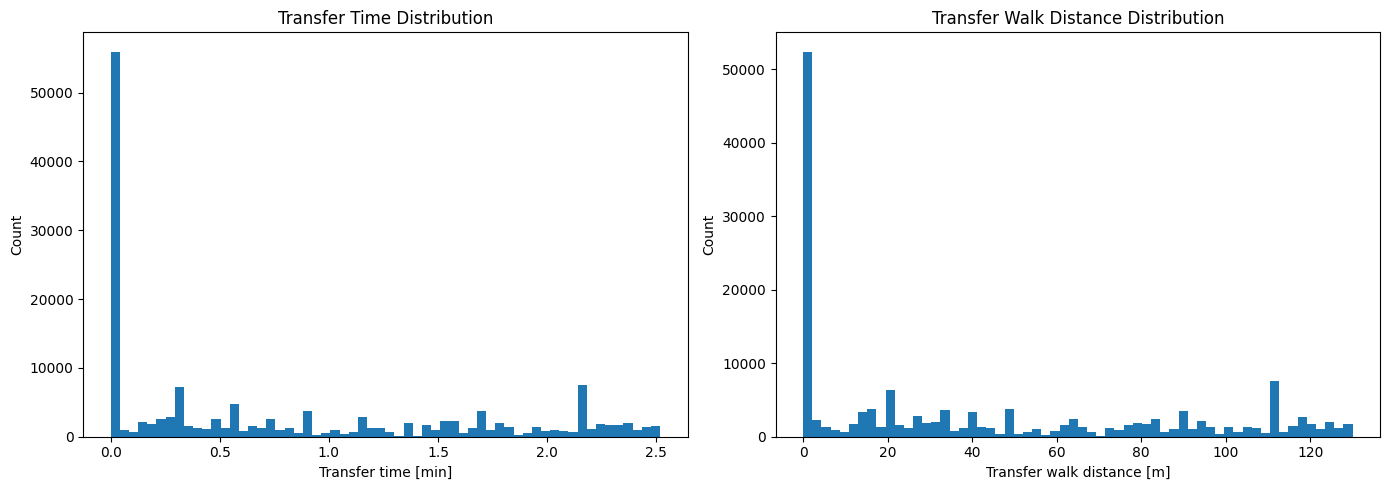

In [10]:
transfers = transfers.copy()
transfers['transfer_time_min'] = transfers['transfer_time_s'] / 60.0
transfers['transfer_distance_m'] = transfers['transfer_distance_m'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(transfers['transfer_time_min'], bins=60)
axes[0].set_title('Transfer Time Distribution')
axes[0].set_xlabel('Transfer time [min]')
axes[0].set_ylabel('Count')

axes[1].hist(transfers['transfer_distance_m'], bins=60)
axes[1].set_title('Transfer Walk Distance Distribution')
axes[1].set_xlabel('Transfer walk distance [m]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
top_transfers = transfers.sort_values(['transfer_time_s', 'transfer_distance_m'], ascending=False).head(10)
top_transfers

,person,trip_id,pt_legs_in_trip,transfer_index,prev_pt_dep_time,prev_pt_arrival_time,next_pt_dep_time,transfer_time_s,transfer_walk_time_s,transfer_wait_time_s,...,prev_transit_line,prev_transit_route,next_transit_line,next_transit_route,prev_egress_stop_id,next_access_stop_id,estimated_walk_speed_kmh,estimated_walk_time_s,estimated_wait_time_s,transfer_time_min
20,person_1000176__women__20_to_24_years__1_basic...,person_1000176__women__20_to_24_years__1_basic...,4,2,10:37:59,13:44:49,13:47:20,151.0,151.0,0.0,...,CP_25-94_24000-94_1008,CP_15166_20251214,UNIR_7012,UNIR_4246_7012_0_3_0800,CP_94_4002.link:199543,UNIR_vlg_310.link:15966,4.0,117.0,34.0,2.516667
33,person_1000255__women__25_to_29_years__highsch...,person_1000255__women__25_to_29_years__highsch...,2,1,09:23:29,09:43:32,09:46:03,151.0,151.0,0.0,...,STCP_303,STCP_303_0_U_5,STCP_602,STCP_602_0_U_19,STCP_CZV4.link:171793,STCP_CZV1.link:74511,4.0,117.0,34.0,2.516667
85,person_1000693__women__60_to_64_years__2_basic...,person_1000693__women__60_to_64_years__2_basic...,4,2,05:55:07,06:31:30,06:34:01,151.0,151.0,0.0,...,CP_25-94_1008-94_38000,CP_15707_20251214,UNIR_2036,UNIR_E-U_2036_0_2_0900,CP_94_38299.link:pt_CP_94_38299,UNIR_ovr_28.link:pt_UNIR_ovr_28,4.0,117.0,34.0,2.516667
164,person_1001349__women__55_to_59_years__1_basic...,person_1001349__women__55_to_59_years__1_basic...,3,2,07:53:49,08:41:29,08:44:00,151.0,151.0,0.0,...,CP_25-94_1008-94_38000,CP_15765_20251214,UNIR_1203,UNIR_A-U_1203_0_2_1330,CP_94_38299.link:pt_CP_94_38299,UNIR_ovr_28.link:pt_UNIR_ovr_28,4.0,117.0,34.0,2.516667
208,person_1001810__women__30_to_34_years__highsch...,person_1001810__women__30_to_34_years__highsch...,3,2,06:23:40,07:20:50,07:23:21,151.0,151.0,0.0,...,CP_25-94_2006-94_38000,CP_15744_20251225,UNIR_1203,UNIR_A-U_1203_0_2_1330,CP_94_38299.link:pt_CP_94_38299,UNIR_ovr_28.link:pt_UNIR_ovr_28,4.0,117.0,34.0,2.516667
941,person_1008504__women__20_to_24_years__1_basic...,person_1008504__women__20_to_24_years__1_basic...,2,1,08:21:39,09:36:04,09:38:35,151.0,151.0,0.0,...,CP_25-94_21071-94_38299,CP_15900_20260518,UNIR_1203,UNIR_A-U_1203_0_2_1330,CP_94_38299.link:pt_CP_94_38299,UNIR_ovr_28.link:pt_UNIR_ovr_28,4.0,117.0,34.0,2.516667
948,person_1008613__women__35_to_39_years__no_educ...,person_1008613__women__35_to_39_years__no_educ...,2,1,10:46:00,14:01:15,14:03:46,151.0,151.0,0.0,...,UNIR_5009,UNIR_A-U_5009_0_1_1050,UNIR_5014,UNIR_A-U_5014_0_1_1230,UNIR_mat_443.link:155807,UNIR_mat_294.link:17124,4.0,117.0,34.0,2.516667
987,person_100880__men__70_to_74_years__highschool...,person_100880__men__70_to_74_years__highschool...,2,1,10:07:34,10:41:27,10:43:58,151.0,151.0,0.0,...,CP_25-94_1008-94_38000,CP_15707_20251214,UNIR_1208,UNIR_A-U_1208_0_2_1830,CP_94_38299.link:pt_CP_94_38299,UNIR_ovr_28.link:pt_UNIR_ovr_28,4.0,117.0,34.0,2.516667
1170,person_1010697__women__50_to_54_years__undergr...,person_1010697__women__50_to_54_years__undergr...,3,1,08:17:39,08:47:00,08:49:31,151.0,151.0,0.0,...,CP_25-94_38000-94_1008,CP_15625_20251214,UNIR_2036,UNIR_A-U_2036_0_2_0915,CP_94_38299.link:pt_CP_94_38299,UNIR_ovr_28.link:pt_UNIR_ovr_28,4.0,117.0,34.0,2.516667
1298,person_1011891__women__50_to_54_years__undergr...,person_1011891__women__50_to_54_years__undergr...,2,1,09:07:25,10:36:03,10:38:34,151.0,151.0,0.0,...,STCP_402,STCP_402_1_U_66,STCP_508,STCP_508_0_U_82,STCP_CZV4.link:171793,STCP_CZV1.link:74511,4.0,117.0,34.0,2.516667


## Transfer Routes Analysis
Analysis of the most common PT line-to-line transfers, stops, and wait times.

In [12]:
# Most common PT line-to-line transfers
# Create a transfer route identifier (line_x -> line_y)
transfers_analysis = transfers.copy()
transfers_analysis['transfer_route'] = (
    transfers_analysis['prev_transit_line'].astype(str) + 
    ' → ' + 
    transfers_analysis['next_transit_line'].astype(str)
)

# Count transfers by route and get statistics
line_transfers = transfers_analysis.groupby('transfer_route', as_index=False).agg({
    'transfer_time_s': ['count', 'mean', 'median', 'min', 'max'],
    'estimated_wait_time_s': ['mean', 'median', 'max'],
    'estimated_walk_time_s': ['mean', 'sum'],
    'transfer_distance_m': ['mean', 'sum'],
}).round(2)

# Flatten column names
line_transfers.columns = ['_'.join(col).strip('_') for col in line_transfers.columns.values]
line_transfers.columns = ['transfer_route', 'count', 'mean_transfer_time_s', 'median_transfer_time_s', 
                          'min_transfer_time_s', 'max_transfer_time_s',
                          'mean_wait_time_s', 'median_wait_time_s', 'max_wait_time_s',
                          'mean_walk_time_s', 'total_walk_time_s',
                          'mean_distance_m', 'total_distance_m']

In [13]:
# Sort by frequency
line_transfers = line_transfers.sort_values('count', ascending=False)

line_transfers[['transfer_route', 'count', 'mean_transfer_time_s', 'mean_wait_time_s', 'mean_distance_m']].head(10)

,transfer_route,count,mean_transfer_time_s,mean_wait_time_s,mean_distance_m
559,Metro_F → Metro_D,2867,0.0,0.0,0.0
469,Metro_D → Metro_C,2415,0.0,0.0,0.0
430,Metro_C → Metro_D,2404,0.0,0.0,0.0
530,Metro_E → Metro_B,2236,0.0,0.0,0.0
470,Metro_D → Metro_E,1877,0.0,0.0,0.0
471,Metro_D → Metro_F,1704,0.0,0.0,0.0
532,Metro_E → Metro_D,1577,0.0,0.0,0.0
478,Metro_D → STCP_500,1572,35.0,5.3,33.0
462,Metro_D → CP_25-94_1008-94_29157,1216,129.0,28.2,112.0
360,Metro_B → Metro_E,1202,0.0,0.0,0.0


In [14]:
transfers_analysis['transfer_route_w_stops'] = (
    transfers_analysis['prev_transit_line'].astype(str) +
        ' @ ' +
    transfers_analysis['prev_egress_stop_id'].astype(str) +
    ' → ' + 
    transfers_analysis['next_transit_line'].astype(str) +
        ' @ ' +
    transfers_analysis['next_access_stop_id'].astype(str)
)

# Count transfers by route and get statistics
line_stop_transfers = transfers_analysis.groupby('transfer_route_w_stops', as_index=False).agg({
    'transfer_time_s': ['count', 'mean', 'median', 'min', 'max'],
    'estimated_wait_time_s': ['mean', 'median', 'max'],
    'estimated_walk_time_s': ['mean', 'sum'],
    'transfer_distance_m': ['mean', 'sum'],
}).round(2)

# Flatten column names
line_stop_transfers.columns = ['_'.join(col).strip('_') for col in line_stop_transfers.columns.values]
line_stop_transfers.columns = ['transfer_route', 'count', 'mean_transfer_time_s', 'median_transfer_time_s', 
                          'min_transfer_time_s', 'max_transfer_time_s',
                          'mean_wait_time_s', 'median_wait_time_s', 'max_wait_time_s',
                          'mean_walk_time_s', 'total_walk_time_s',
                          'mean_distance_m', 'total_distance_m']

#time in minutes
for col in line_stop_transfers.columns:
    if 'time_s' in col:
        line_stop_transfers[col.replace('_s', '_m')] = line_stop_transfers[col] / 60.0

In [15]:
# Sort by frequency
line_stop_transfers = line_stop_transfers.sort_values(['mean_transfer_time_s','count'], ascending=False)

# Filter routes with at least 10 transfers for meaningful statistics
significant_routes = line_stop_transfers[line_stop_transfers['count'] >= 10]
significant_routes[['transfer_route', 'count', 'mean_transfer_time_m', 'mean_wait_time_m', 'mean_distance_m']].head(10)

,transfer_route,count,mean_transfer_time_m,mean_wait_time_m,mean_distance_m
171,CP_25-94_21071-94_38299 @ CP_94_38299.link:pt_...,199,2.516667,0.566667,130.0
173,CP_25-94_21071-94_38299 @ CP_94_38299.link:pt_...,159,2.516667,0.566667,130.0
579,Metro_D @ Metro_5767.link:pt_Metro_5767 → UNIR...,116,2.516667,0.566667,130.0
57,CP_25-94_1008-94_38000 @ CP_94_38299.link:pt_C...,79,2.516667,0.566667,130.0
55,CP_25-94_1008-94_38000 @ CP_94_38299.link:pt_C...,76,2.516667,0.566667,130.0
1012,STCP_402 @ STCP_CZV4.link:171793 → STCP_508 @ ...,74,2.516667,0.566667,130.0
144,CP_25-94_2006-94_38000 @ CP_94_38299.link:pt_C...,66,2.516667,0.566667,130.0
219,CP_25-94_24000-94_1008 @ CP_94_4002.link:19954...,41,2.516667,0.566667,130.0
1241,STCP_601 @ STCP_PRG2.link:1493 → STCP_200 @ ST...,39,2.516667,0.566667,130.0
272,CP_25-94_38000-94_1008 @ CP_94_38299.link:pt_C...,35,2.516667,0.566667,130.0


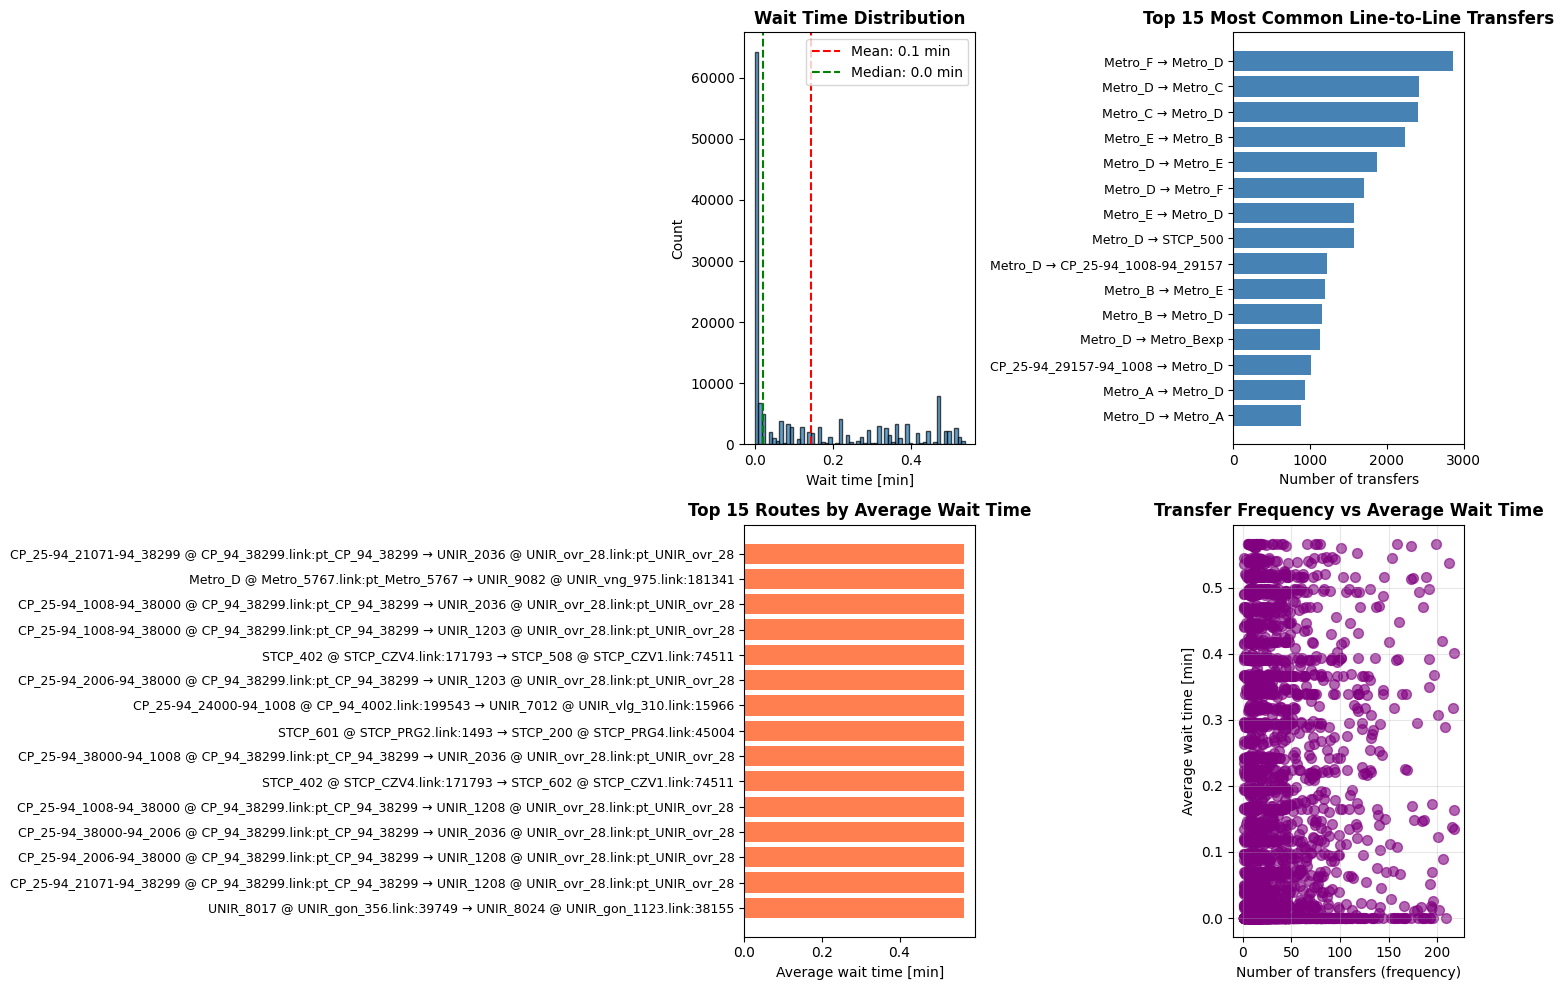

In [16]:
# Visualizations: Distribution of wait times and top transfers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Wait time distribution
wait_times_min = transfers_analysis['estimated_wait_time_s'] / 60
wait_times_min = wait_times_min[wait_times_min.between(wait_times_min.quantile(0.025), wait_times_min.quantile(0.975))]
axes[0, 0].hist(wait_times_min, bins=60, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Wait Time Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Wait time [min]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(wait_times_min.mean(), color='red', linestyle='--', label=f'Mean: {wait_times_min.mean():.1f} min')
axes[0, 0].axvline(wait_times_min.median(), color='green', linestyle='--', label=f'Median: {wait_times_min.median():.1f} min')
axes[0, 0].legend()

# Plot 2: Top 15 routes by frequency
top_15_routes = line_transfers.head(15)
axes[0, 1].barh(range(len(top_15_routes)), top_15_routes['count'], color='steelblue')
axes[0, 1].set_yticks(range(len(top_15_routes)))
axes[0, 1].set_yticklabels(top_15_routes['transfer_route'], fontsize=9)
axes[0, 1].set_xlabel('Number of transfers')
axes[0, 1].set_title('Top 15 Most Common Line-to-Line Transfers', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
#for i, v in enumerate(top_15_routes['count']): axes[0, 1].text(v + 50, i, str(int(v)), va='center')

# Plot 3: Top 15 routes by average wait time (only routes with 10+ transfers)
top_15_wait = line_stop_transfers[line_stop_transfers['count'].between(line_stop_transfers['count'].quantile(0.025), line_stop_transfers['count'].quantile(0.975))].head(15)
axes[1, 0].barh(range(len(top_15_wait)), top_15_wait['mean_wait_time_m'], color='coral')
axes[1, 0].set_yticks(range(len(top_15_wait)))
axes[1, 0].set_yticklabels(top_15_wait['transfer_route'], fontsize=9)
axes[1, 0].set_xlabel('Average wait time [min]')
axes[1, 0].set_title('Top 15 Routes by Average Wait Time', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
#for i, v in enumerate(top_15_wait['mean_wait_time_m']):axes[1, 0].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)

# Plot 4: Relationship between transfer frequency and average wait time
transferCounts = line_transfers[line_transfers['count'].between(line_transfers['count'].quantile(0.025), line_transfers['count'].quantile(0.975))]
axes[1, 1].scatter(transferCounts['count'], transferCounts['mean_wait_time_s'] / 60, 
                   s=50, alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Number of transfers (frequency)')
axes[1, 1].set_ylabel('Average wait time [min]')
axes[1, 1].set_title('Transfer Frequency vs Average Wait Time', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()